In [1]:
import pandas as pd
import numpy as np
from utils import plot
from statsmodels.tsa.api import VAR

In [2]:
df = pd.read_csv('wbtc_train_data_expanded.csv')

nav = df['nav'].values
nect_price = df['nect_price'].values
vol_token_price = df['wbtc_price'].values
volatile_part = df['wbtc_frac'].values
timestamps = df['timestamp'].values

df_amounts = pd.read_csv('wbtc_token_amounts_data.csv')
total_supply = df_amounts['island_token_balance'].values
stable_token_balance = df_amounts['honey_balance'].values
vol_token_balance = df_amounts['wbtc_balance'].values

total_supply = total_supply[len(vol_token_balance) - len(vol_token_price):]
stable_token_balance = stable_token_balance[len(vol_token_balance) - len(vol_token_price):]
vol_token_balance = vol_token_balance[len(vol_token_balance) - len(vol_token_price):]

6.096488553396355e-06 0.0004868141613705003
-2.20949784582445e-06 0.002859470286952047
-1.2410384025896776e-05 0.002641502701385392
-6.272759016659789e-06 0.001851549810493781


c:\Proga\leverege_simul\for_server\model_train\statistic\utils.py:28: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


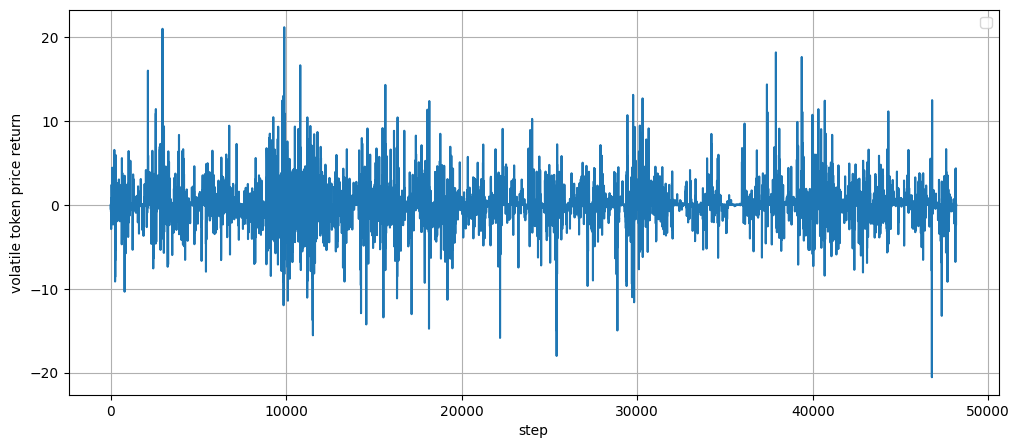

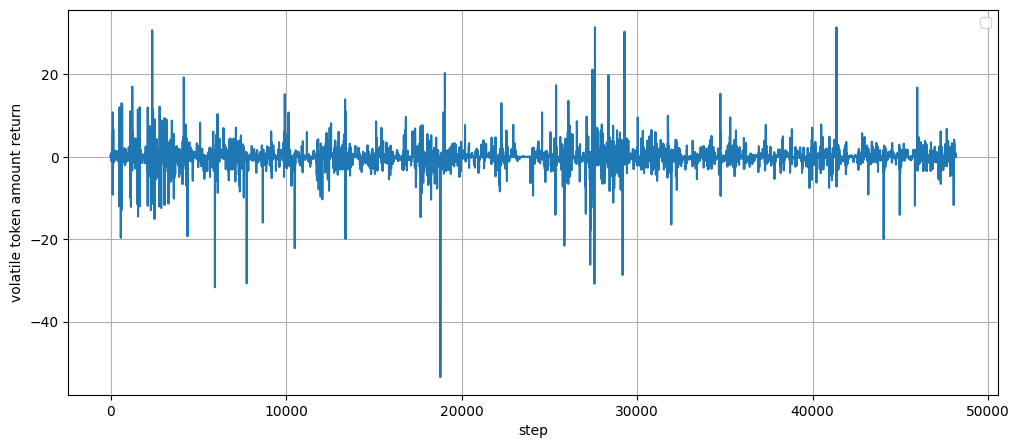

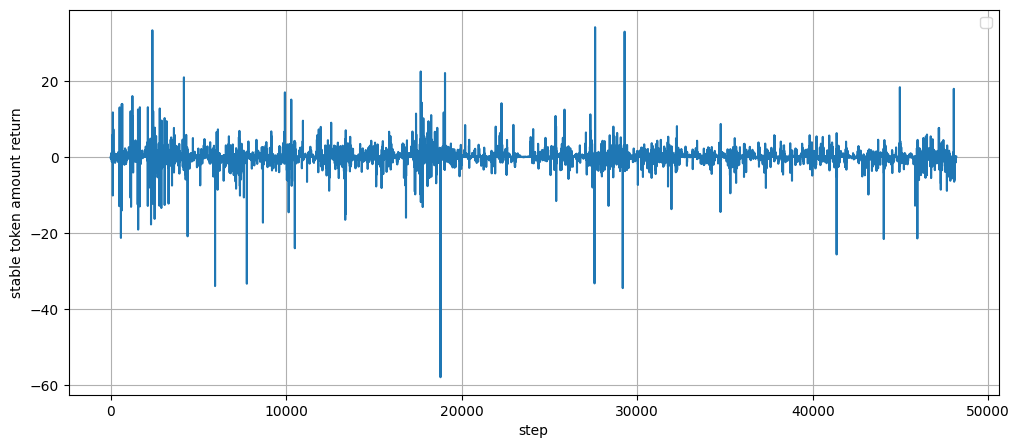

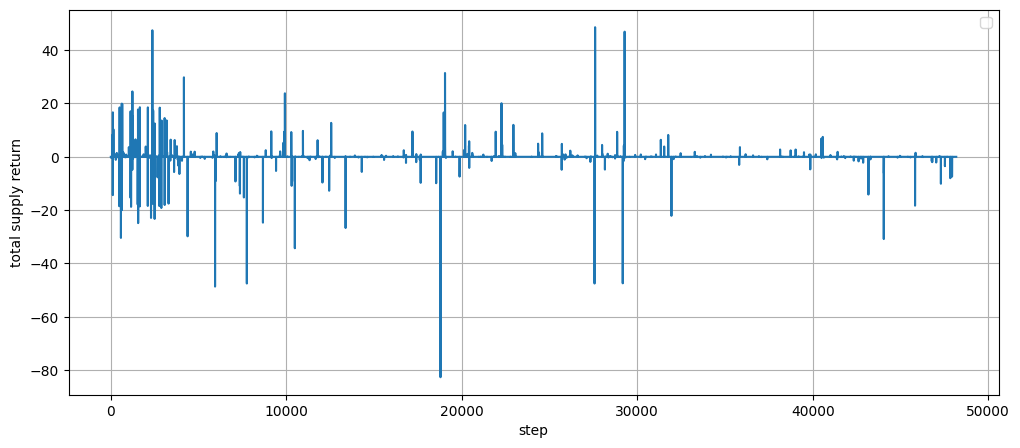

In [3]:
p_r = np.diff(np.log(vol_token_price))
v_r = np.diff(np.log(vol_token_balance))
s_r = np.diff(np.log(stable_token_balance))
ts_r = np.diff(np.log(total_supply))

print(np.mean(p_r), np.std(p_r))
print(np.mean(v_r), np.std(v_r))
print(np.mean(s_r), np.std(s_r))
print(np.mean(ts_r), np.std(ts_r))

p_r_normed = p_r/np.std(p_r)
v_r_normed = v_r/np.std(v_r)
s_r_normed = s_r/np.std(s_r)
ts_r_normed = ts_r/np.std(ts_r)

plot(
    [p_r_normed],
    'step',
    'volatile token price return'
)

plot(
    [v_r_normed],
    'step',
    'volatile token amount return'
)

plot(
    [s_r_normed],
    'step',
    'stable token amount return'
)

plot(
    [ts_r_normed],
    'step',
    'total supply return'
)

In [4]:
returns = pd.DataFrame({
    'S1': p_r_normed, 
    'S2': v_r_normed, 
    'S3': s_r_normed, 
    'S4': ts_r_normed
})

model = VAR(returns)
results = model.fit(maxlags=20, ic='bic')

A_mats = results.coefs
Sigma_u = results.sigma_u

print("Selected lag order:", results.k_ar)
print("\nIs VAR stable?:", results.is_stable(verbose=True))
print(results.summary())

#results.save("wbtc_island_var_model.pkl")

Selected lag order: 3
Eigenvalues of VAR(1) rep
0.2502791260600908
0.3930181128752776
0.3930181128752776
0.3047144239822338
0.3047144239822338
0.3362159278385245
0.3362159278385245
0.2622211141767822
0.2622211141767822
0.5200083707776448
0.5471605497773562
0.5774366928143313

Is VAR stable?: True
  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Tue, 11, Nov, 2025
Time:                     18:42:29
--------------------------------------------------------------------
No. of Equations:         4.00000    BIC:                   -3.65410
Nobs:                     48176.0    HQIC:                  -3.66061
Log likelihood:          -185135.    FPE:                  0.0256406
AIC:                     -3.66358    Det(Omega_mle):       0.0256129
--------------------------------------------------------------------
Results for equation S1
           coefficient       std. error           t-stat            prob
----------------

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_14392\80134765.py:8: FutureWarning: the 'maxlag' keyword is deprecated, use 'nlags' instead.
  lm_stat, lm_p, f_stat, f_p = het_arch(resid[col]/np.std(resid[col]), maxlag=5)


S1: ARCH LM p = 2.125e-273


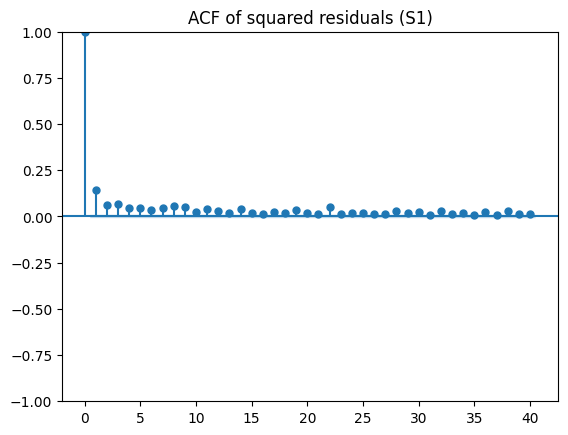

S2: ARCH LM p = 7.940e-05


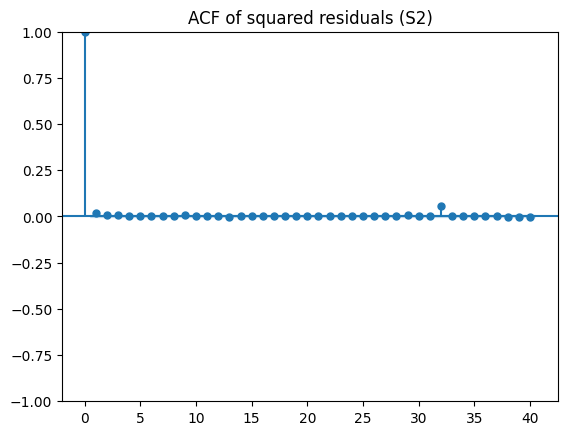

S3: ARCH LM p = 4.586e-02


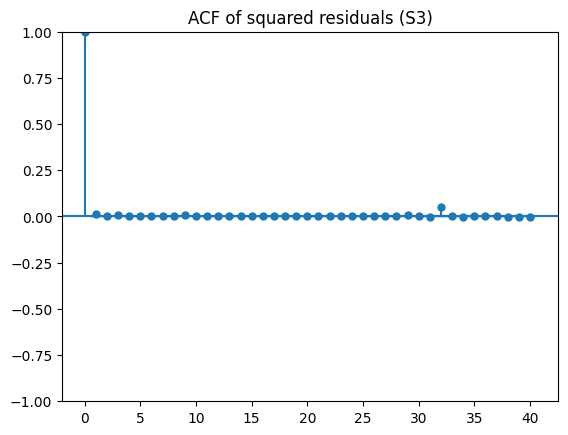

S4: ARCH LM p = 9.954e-01


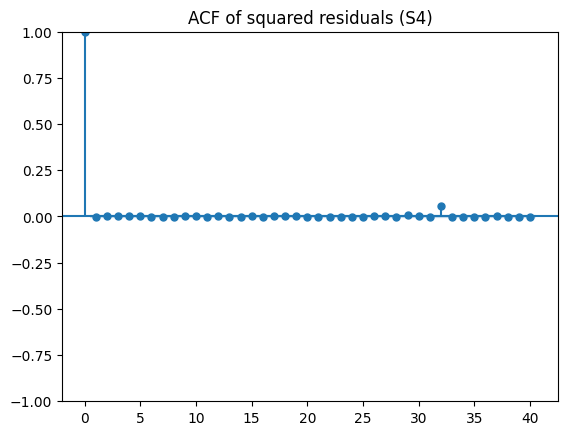

In [16]:
from statsmodels.stats.diagnostic import het_arch
from statsmodels.graphics.tsaplots import plot_acf
import matplotlib.pyplot as plt

resid = results.resid

for col in resid.columns:
    lm_stat, lm_p, f_stat, f_p = het_arch(resid[col]/np.std(resid[col]), maxlag=5)
    print(f"{col}: ARCH LM p = {lm_p:.3e}")
    plot_acf(resid[col]**2, lags=40)
    plt.title(f"ACF of squared residuals ({col})")
    plt.show()

In [ ]:
from arch import arch_model

def try_garch_orders(series, max_p=4, max_q=4):
    results = []
    y = series/np.std(series)

    for p in range(1, max_p+1):
        for q in range(1, max_q+1):
            try:
                am = arch_model(y, mean='Zero', vol='Garch', p=p, q=q, dist='t')
                res = am.fit(disp='off')
                
                std_resid = res.std_resid
                lm_stat, lm_p, _, _ = het_arch(std_resid, maxlag=5)

                alpha_sum = sum(res.params.get(f'alpha[{i}]', 0) for i in range(1, p+1))
                beta_sum  = sum(res.params.get(f'beta[{j}]', 0) for j in range(1, q+1))

                results.append({
                    "p": p,
                    "q": q,
                    "AIC": res.aic,
                    "BIC": res.bic,
                    "alpha+beta": alpha_sum + beta_sum,
                    "ARCH_p": lm_p
                })
            except Exception as e:
                results.append({
                    "p": p, "q": q, "AIC": float('inf'),
                    "BIC": float('inf'), "alpha+beta": None,
                    "ARCH_p": None
                })

    return pd.DataFrame(results).sort_values("AIC")

s1_res = try_garch_orders(resid["S1"], max_p=10, max_q=10)
print(s1_res)

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_14392\1064198487.py:15: FutureWarning: the 'maxlag' keyword is deprecated, use 'nlags' instead.
  lm_stat, lm_p, _, _ = het_arch(std_resid, maxlag=5)
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_14392\1064198487.py:15: FutureWarning: the 'maxlag' keyword is deprecated, use 'nlags' instead.
  lm_stat, lm_p, _, _ = het_arch(std_resid, maxlag=5)
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_14392\1064198487.py:15: FutureWarning: the 'maxlag' keyword is deprecated, use 'nlags' instead.
  lm_stat, lm_p, _, _ = het_arch(std_resid, maxlag=5)
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_14392\1064198487.py:15: FutureWarning: the 'maxlag' keyword is deprecated, use 'nlags' instead.
  lm_stat, lm_p, _, _ = het_arch(std_resid, maxlag=5)
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_14392\1064198487.py:15: FutureWarning: the 'maxlag' keyword is deprecated, use 'nlags' instead.
  lm_stat, lm_p, _, _ = het_arch(std_resid, maxlag=5)
C:\Users\Lenovo\AppData\L

     p   q           AIC           BIC  alpha+beta        ARCH_p
75   8   6 -49166.179650 -49025.657790    0.878377  5.349154e-01
96  10   7 -44887.751769 -44720.882060    1.064826  5.214585e-01
78   8   9 -41542.844294 -41375.974585    0.277458  6.234387e-01
68   7   9 -41130.510166 -40972.423074    1.211534  8.734691e-01
79   8  10 -38621.678502 -38446.026177    0.498510  5.722692e-01
..  ..  ..           ...           ...         ...           ...
88   9   9  74830.098514  75005.750839    0.900000  5.061153e-09
61   7   2  74977.668528  75074.277307    0.980000  2.799522e-32
98  10   9  75066.906948  75251.341890    0.900000  1.135046e-10
71   8   2  75167.802919  75273.194314    0.980000  2.339185e-37
99  10  10  75341.309688  75534.527245    0.900000  4.581755e-11

[100 rows x 6 columns]


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_14392\1064198487.py:15: FutureWarning: the 'maxlag' keyword is deprecated, use 'nlags' instead.
  lm_stat, lm_p, _, _ = het_arch(std_resid, maxlag=5)


In [21]:
from statsmodels.stats.diagnostic import het_arch, acorr_ljungbox

def check_garch_dit(s, p, q, dist = 'normal'):
    x = resid[s]/np.std(resid[s])

    am = arch_model(x, mean='Zero', vol='Garch', p=p, q=q, dist=dist)
    res = am.fit(disp='off')
    print(res.summary())

    std_resid = res.std_resid

    # ARCH LM on standardized residuals
    lm_stat, lm_p, _, _ = het_arch(std_resid, maxlag=5)

    # Ljung–Box on squared standardized residuals
    lb_res = acorr_ljungbox(std_resid**2, lags=[10], return_df=True)

    print("Series", s)
    print("Scale:", np.std(resid[s]))
    print("ARCH LM p:", float(lm_p))
    print("Ljung–Box (squared) p (lag 10):", float(lb_res['lb_pvalue'].iloc[-1]))

In [78]:
check_garch_dit('S4', 1, 1, 'normal')

                       Zero Mean - GARCH Model Results                        
Dep. Variable:                     S4   R-squared:                       0.000
Mean Model:                 Zero Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -63816.0
Distribution:                  Normal   AIC:                           127638.
Method:            Maximum Likelihood   BIC:                           127664.
                                        No. Observations:                48176
Date:                Tue, Nov 11 2025   Df Residuals:                    48176
Time:                        20:59:01   Df Model:                            0
                               Volatility Model                              
                 coef    std err          t      P>|t|       95.0% Conf. Int.
-----------------------------------------------------------------------------
omega          0.0132  4.506e-02      0.292      0.770 

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_14392\3567607391.py:13: FutureWarning: the 'maxlag' keyword is deprecated, use 'nlags' instead.
  lm_stat, lm_p, _, _ = het_arch(std_resid, maxlag=5)


Series S4
Scale: 0.9997608842747774
ARCH LM p: 0.9999998322063176
Ljung–Box (squared) p (lag 10): 0.9999999999996165
